# Template notebook for opening and processing face database

This notebook shows you how to open up the face database, extract the required faces and then display them, which will be useful for your assignment.

The face database is stored in a special format called *HDF5* (Hierarchical Data Format), which is used by companies and research institutions (such as NASA) to store huge amounts of data in a structured format.  Python uses the h5py library to open, create, read and write HDF5.

Let us start by importing the necessary libraries

In [1]:
import numpy as np
import h5py as h5  # <-- here is the h5py library
import matplotlib.pyplot as plt

## Defining parameters

We now start off by defining some parameters.  The face database we will use has 10 faces from 40 different people.  Each image has dimensions of $64\times 64$ pixels.  The database has been randomised and split into a 70/30 portions for the training and test set.  Equivalently, there are:
- 280 faces in the training set; and
- 120 faces in the test set.

In [2]:
Ns = 40  # number of subjects
Nf = 10  # number of faces per subject
dim = 64 * 64  # dimension of the image

Ntrain = 200
Nvalid = 80
Ntest = 120

## Opening up the HDF5 file

The file is provided on Learning@Griffith and is called "facedb.hdf5".  Make sure this file is in the same folder as this notebook.  As you can see below, the 'hf' variable is a "handle" to the data.  We will use to access several arrays inside

In [3]:
hf = h5.File("facedb.hdf5", "r")  # open the file in reading mode "r"

It will be helpful to download the HDFView program, which will allow you to see what is inside the HDF5 file, as well as the folder structure within it.  You can download the HDFView program from Learning@Griffith (Windows and Mac OS versions)

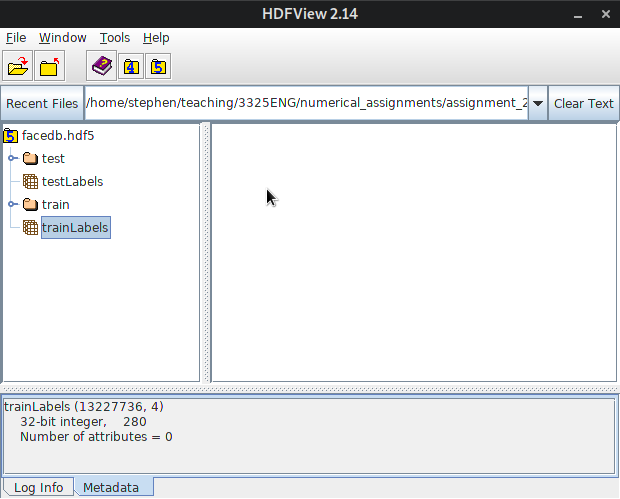

You can see there there are two folders named "train" and "test", which contain the arrays of $64\times 64$ for each face.  Also, there are two arrays (called **datasets** in HDF5 terminology) called "trainLabels" and "testLabels".  

These two arrays contain the respective labels of faces in the training/test sets, i.e. which person's ID.  These will be useful for training and testing.  You can double click on a dataset to see the contents.

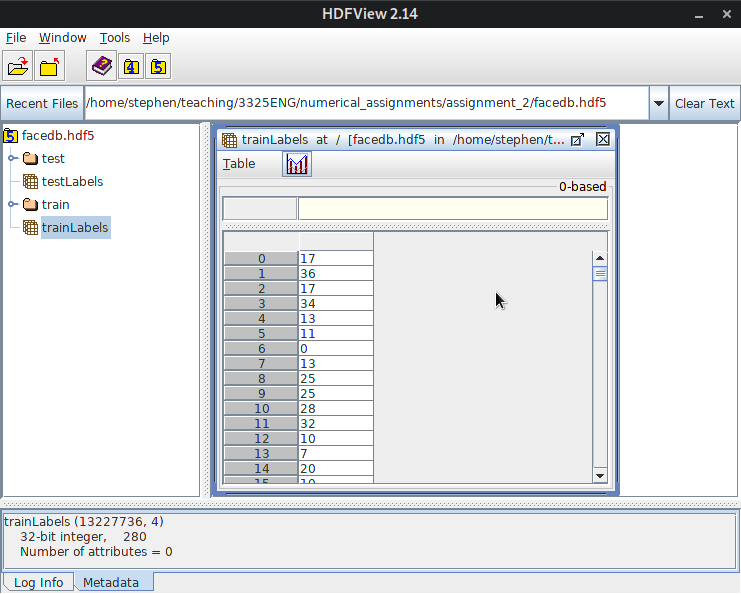


For example, we can see that the first face in the training set belongs to person 17, while the next face belong to person 36, and so on.

## Opening a dataset

Let us open the two datasets "trainLabels" and "testLabels" into Python as numpy arrays.  Note that the 'hf' variable we opened earlier is actually a **dictionary**, so we can use the text as indices in an array notation.

In [4]:
trLabels = hf["trainLabels"][:]
tsLabels = hf["testLabels"][:]
vLabels = hf["validLabels"][:]  # validation set labels

print(trLabels.shape)
print(tsLabels.shape)
print(vLabels.shape)

(200,)
(120,)
(80,)


Note that under the train and test folders, there are in fact **lots of** datasets.  The question is how do we traverse all of them automatically (without having the manually enter them into the code)?

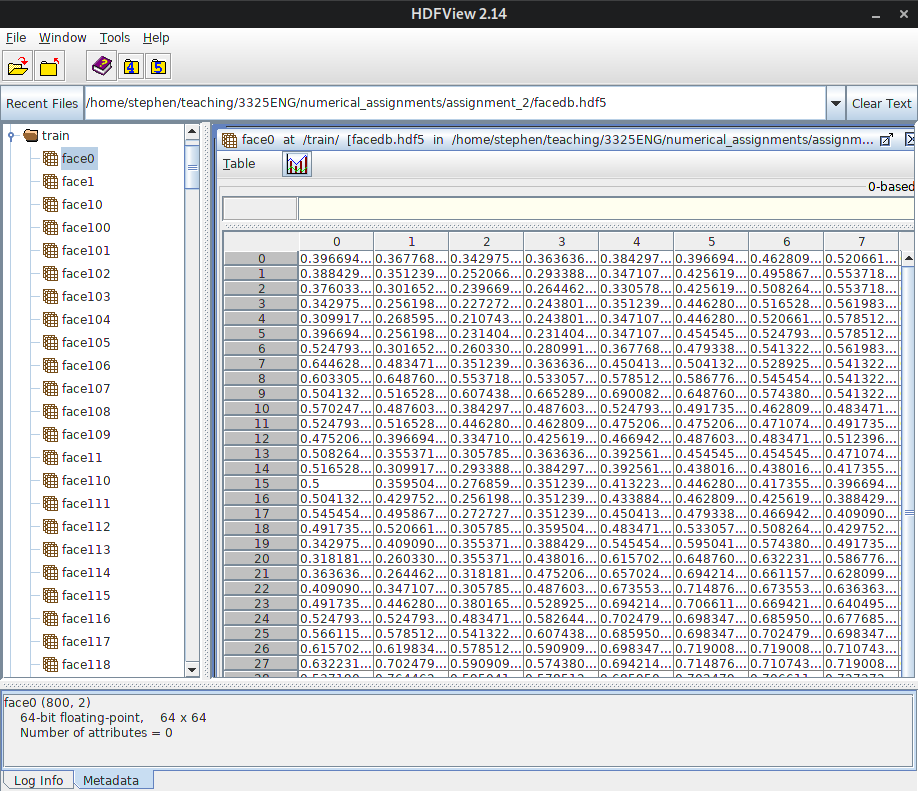

We can do so by simply using the trusty **for loop** to cycle through each dataset automagically. More importantly, the numerical index is increased in ascending order as well.  

For example, the label in say index 5 in the trainLabels array is the label of 'face5'.

In [ ]:
faceIndex = []

for f in range(280):
	face = "face" + str(f)  # create the string and append with the index
	print(face)
	faceIndex.append(face)  # store these face names in a list for future use

Hence we can use this as our "index" to grab each array.  Note the **two sets** of square brackets ["train"][face]

In [ ]:
for f in range(280):
	face = "face" + str(f)  # create the string and append with the index
	image = hf["train"][face]
	
	print("Shape of", face, ":", image.shape)

## Displaying the face images

To display the faces, we can use the **imshow()** function from matplotlib.  Let us plot the first 25 faces using subplots

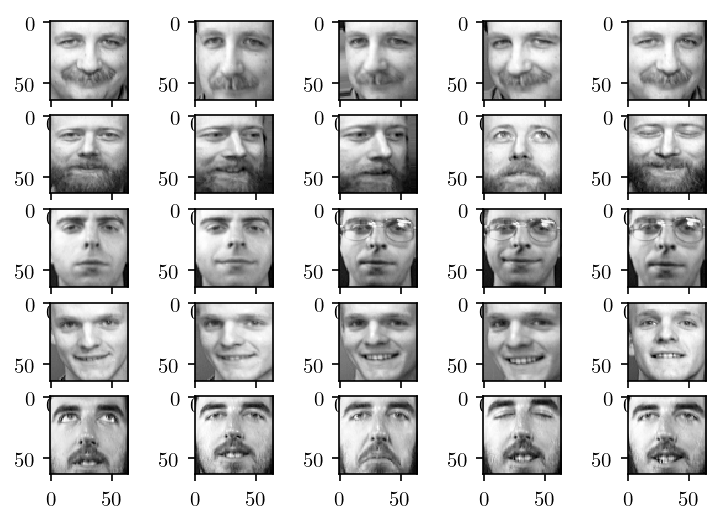

In [8]:
plt.figure(dpi=150)

for count in range(25):
	plt.subplot(5, 5, count + 1)
	plt.imshow(hf["train"][faceIndex[count]], cmap = "gray")
	count += 1

## Reshaping the face arrays

As you saw before, **imshow()** requires the matrix to be 2D (the dimensions were $64\times 64$).  However, in your assignment, we will need to convert each face image to a 1D array for use in feature extraction.

You can convert a 2D array into 1D by using the reshape() function, as shown below.

In [9]:
# grab say the first face
face = hf["train"]["face0"]

print(face.shape)  # this is the shape of the original 2D array

face2 = np.reshape(face, 4096)  # reshape it to a 1D array of length 64 x 64 = 4096

print(face2.shape)

(64, 64)
(4096,)


## Closing the HDF5 file

Remember to close the HDF file after we have finished!

In [10]:
hf.close()